# Prediction du prix TTF

# Création du dataset

In [2]:
%load_ext autoreload
%autoreload 2
#Basic Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### TTF

In [3]:
base_path = '../data/raw/'

def load_price_csv(filename, price_col_name):
    df = pd.read_csv(f'{base_path}/{filename}')
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df = df.sort_values('Date').reset_index(drop=True)
    return df[['Date', 'Price']].rename(columns={'Date': 'date', 'Price': price_col_name})


In [4]:
ttf_clean = load_price_csv('Dutch_TTF_Natural_Gas_Futures_Historical_Data.csv', 'prix_ttf_eur_per_mwh')


In [5]:
ttf_clean.head()

,date,prix_ttf_eur_per_mwh
0,2017-10-23,18.09
1,2017-10-24,17.96
2,2017-10-25,18.11
3,2017-10-26,18.07
4,2017-10-27,18.15


#### Brent (Oil)

In [6]:
brent_clean = load_price_csv('Brent_Oil_Futures_Historical_Data.csv', 'prix_brent_usd_per_bbl')


In [7]:
brent_clean.head()

,date,prix_brent_usd_per_bbl
0,2015-01-27,49.60
1,2015-01-28,48.47
2,2015-01-29,49.13
3,2015-01-30,52.99
4,2015-02-02,54.75


#### HenryHub (US Natural Gas)

In [8]:
henry_hub_clean = load_price_csv('Natural_Gas_Futures_Historical_Data.csv', 'prix_henry_hub_usd_per_mmbtu')


In [9]:
henry_hub_clean.head()

,date,prix_henry_hub_usd_per_mmbtu
0,2015-01-01,2.841
1,2015-01-02,3.003
2,2015-01-05,2.882
3,2015-01-06,2.938
4,2015-01-07,2.871


#### JKM (Asian Natural Gas)

In [10]:
jkm_clean = load_price_csv('Japan_Korea_Marker_Historical_Data.csv', 'prix_jkm_usd_per_mmbtu')


In [11]:
jkm_clean.head()

,date,prix_jkm_usd_per_mmbtu
0,2015-01-02,10.055
1,2015-01-05,10.005
2,2015-01-06,9.985
3,2015-01-07,9.985
4,2015-01-08,9.975


#### EU Coal

In [12]:
eucoal_clean = load_price_csv('EU_coal_Futures_Historical_Data.csv', 'prix_charbon_usd_per_tonne')


In [13]:
eucoal_clean.head()

,date,prix_charbon_usd_per_tonne
0,2015-01-02,65.50
1,2015-01-05,63.75
2,2015-01-06,62.70
3,2015-01-07,60.85
4,2015-01-08,60.60


#### EUA (European Carbon Permit)

In [14]:
eua_clean = load_price_csv('EU_Carbon_Permit_Historical_Data.csv', 'prix_co2_eur_per_tonne')


In [15]:
eua_clean.head()

,date,prix_co2_eur_per_tonne
0,2015-01-02,7.09
1,2015-01-05,6.99
2,2015-01-06,6.86
3,2015-01-07,6.87
4,2015-01-08,6.90


#### FX Rate EUR/USD

In [16]:
eur_usd_clean = load_price_csv('EUR_USD_Historical_Data.csv', 'taux_eur_usd')


In [17]:
eur_usd_clean.head()

,date,taux_eur_usd
0,2015-01-01,1.2102
1,2015-01-02,1.2000
2,2015-01-05,1.1931
3,2015-01-06,1.1888
4,2015-01-07,1.1837


#### Storage level (AGSI+)

In [18]:
import pandas as pd

agsi = pd.read_csv(f'{base_path}/StorageData_GIE_2015-01-01_2026-05-23.csv',
                    sep=';', quotechar='"')

agsi['Gas Day Start'] = pd.to_datetime(agsi['Gas Day Start (status at 6AM  CEST)'])
agsi = agsi.sort_values('Gas Day Start').reset_index(drop=True)


agsi_clean = agsi[['Gas Day Start', 'Full (%)']].copy()
agsi_clean.columns = ['date', 'agsi_pct_capacity']


agsi_clean.head()

,date,agsi_pct_capacity
0,2015-01-01,73.02
1,2015-01-02,72.54
2,2015-01-03,72.13
3,2015-01-04,71.71
4,2015-01-05,71.13


#### Weather (Paris, Amsterdam, Berlin)

In [19]:
import requests

# Infos récupérées sur le site Open-Meteo
cities = {
    'amsterdam': {'lat': 52.3676, 'lon': 4.9041},
    'berlin': {'lat': 52.52, 'lon': 13.40},
    'paris': {'lat': 48.8566, 'lon': 2.3522}
}

url = "https://archive-api.open-meteo.com/v1/archive"

all_temps = []

for city, coords in cities.items():

    params = {
        'latitude': coords['lat'],
        'longitude': coords['lon'],
        'start_date': '2015-01-01',
        'end_date': '2026-05-25',
        'daily': 'temperature_2m_mean',
        'timezone': 'UTC'
    }


    response = requests.get(url, params=params)
    data = response.json()

    temps_df = pd.DataFrame({
        'date': data['daily']['time'],
        f'temp_{city}_celsius': data['daily']['temperature_2m_mean']
    })

    temps_df['date'] = pd.to_datetime(temps_df['date'])
    all_temps.append(temps_df)

weather = all_temps[0]
for df in all_temps[1:]:
    weather = weather.merge(df, on='date', how='outer')

weather = weather.sort_values('date').reset_index(drop=True)

In [20]:
weather

,date,temp_amsterdam_celsius,temp_berlin_celsius,temp_paris_celsius
0,2015-01-01,3.7,2.6,-0.6
1,2015-01-02,7.6,4.9,5.0
2,2015-01-03,5.2,3.8,6.8
3,2015-01-04,4.9,2.9,3.7
4,2015-01-05,3.8,2.9,0.2
...,...,...,...,...
4158,2026-05-21,15.9,16.6,17.7
4159,2026-05-22,19.3,18.4,20.7
4160,2026-05-23,20.7,21.7,22.7
4161,2026-05-24,19.1,22.1,24.2


#### Fusion des données

In [21]:
# Fusion de toutes les sources sur 'date'
# (inner join pour ne garder que les jours communs)
df_raw = (
    ttf_clean
    .merge(brent_clean, on='date', how='inner')
    .merge(henry_hub_clean, on='date', how='inner')
    .merge(jkm_clean, on='date', how='inner')
    .merge(eucoal_clean, on='date', how='inner')
    .merge(eua_clean, on='date', how='inner')
    .merge(eur_usd_clean, on='date', how='inner')
    .merge(agsi_clean, on='date', how='inner')
    .merge(weather, on='date', how='inner')
)

# On garde le dataset à partir de la date
# ou toutes les colonnes ont une valeur
premiere_date_complete = df_raw.dropna().iloc[0]['date']

df_raw = df_raw[df_raw['date'] >= premiere_date_complete].reset_index(drop=True)

# Gestion des NaN residuels (jours feries d'un seul marche, retard de publication AGSI, ...)
# Strategie : forward fill
# Justification : prix et stockage gaz evoluent lentement,
# la derniere valeur connue est la meilleure estimation d'un jour sans cotation.
nan_restants = df_raw.isna().sum().sum()
if nan_restants > 0:
    print(f"NaN residuels detectes : {nan_restants} -> forward fill")
    df_raw = df_raw.ffill()


# Sauvegarde
df_raw.to_csv('../data/clean/dataset_raw.csv')


## Feature engineering

### 2.1 Features Calendaires

- **jour_semaine** : impact des variations intra-semaine sur la demande gaz
- **mois** : saisonnalite annuelle (hiver = pic chauffage)
- **annee** : tendance longue (transition energetique, crises)
- **trimestre** : segmentation saisonniere plus large
- **est_weekend** : demande industrielle reduite samedi/dimanche
- **est_lundi** : effet rebond apres weekend sur les marches
- **num_jour_annee** : position cyclique dans l'annee

In [22]:
# Decomposition de la date en features temporelles
df_raw['jour_semaine']   = df_raw['date'].dt.dayofweek      # 0 = lundi, 6 = dimanche
df_raw['mois']           = df_raw['date'].dt.month
df_raw['annee']          = df_raw['date'].dt.year
df_raw['trimestre']      = df_raw['date'].dt.quarter
df_raw['est_weekend']    = (df_raw['jour_semaine'] >= 5).astype(int)
df_raw['est_lundi']      = (df_raw['jour_semaine'] == 0).astype(int)
df_raw['num_jour_annee'] = df_raw['date'].dt.dayofyear

df_raw[['date','jour_semaine','mois','annee','trimestre','est_weekend','est_lundi','num_jour_annee']].head()

,date,jour_semaine,mois,annee,trimestre,est_weekend,est_lundi,num_jour_annee
0,2017-10-23,0,10,2017,4,0,1,296
1,2017-10-24,1,10,2017,4,0,0,297
2,2017-10-25,2,10,2017,4,0,0,298
3,2017-10-26,3,10,2017,4,0,0,299
4,2017-10-27,4,10,2017,4,0,0,300


### 2.2 Features Thermiques

- **temp_moyenne_eur** : moyenne des temperatures Paris / Amsterdam / Berlin (proxy zone TTF)
- **hdd** : Heating Degree Days, indicateur de demande thermique (chaque degre sous 15 C = +1 demande chauffage)

In [23]:
# Temperature moyenne des 3 capitales de la zone TTF
df_raw['temp_moyenne_eur'] = df_raw[[
    'temp_amsterdam_celsius',
    'temp_berlin_celsius',
    'temp_paris_celsius'
]].mean(axis=1)

# Heating Degree Days : max(0, 15 - temp)
df_raw['hdd'] = (15 - df_raw['temp_moyenne_eur']).clip(lower=0)

df_raw[['date','temp_moyenne_eur','hdd']].head()

,date,temp_moyenne_eur,hdd
0,2017-10-23,11.633333,3.366667
1,2017-10-24,13.700000,1.300000
2,2017-10-25,14.400000,0.600000
3,2017-10-26,12.766667,2.233333
4,2017-10-27,11.533333,3.466667


### 2.3 Ratios Cross-Produits

- **ratio_brent_ttf** : spread arbitrage petrole brut vs gaz europeen (substitution energetique)
- **ratio_ttf_henry_hub** : spread arbitrage gaz Europe vs gaz US (flux GNL trans-atlantiques) - henry_hub converti en MWh via x 3.6
- **ratio_jkm_henry_hub** : spread arbitrage gaz Asie vs gaz US (flux GNL trans-pacifiques)

In [24]:
# Ratios entre commodites (proxys d'arbitrage et de flux GNL)
df_raw['ratio_brent_ttf']      = df_raw['prix_brent_usd_per_bbl'] / df_raw['prix_ttf_eur_per_mwh']
df_raw['ratio_ttf_henry_hub']  = df_raw['prix_ttf_eur_per_mwh']   / (df_raw['prix_henry_hub_usd_per_mmbtu'] * 3.6)
df_raw['ratio_jkm_henry_hub']  = df_raw['prix_jkm_usd_per_mmbtu'] / df_raw['prix_henry_hub_usd_per_mmbtu']

df_raw[['date','ratio_brent_ttf','ratio_ttf_henry_hub','ratio_jkm_henry_hub']].head()

,date,ratio_brent_ttf,ratio_ttf_henry_hub,ratio_jkm_henry_hub
0,2017-10-23,3.171365,1.592205,2.794677
1,2017-10-24,3.247773,1.591352,2.813397
2,2017-10-25,3.226946,1.632237,2.850422
3,2017-10-26,3.281682,1.645180,2.900688
4,2017-10-27,3.330028,1.700967,3.034750


### 2.4 Volatilite

- **volatilite_atr14** : volatilite implicite du marche sur 14 jours (proxy du risque court terme).
  ATR "vrai" demande OHLC, on approxime ici avec la moyenne mobile 14j des variations absolues de cloture.

In [25]:
# ATR 14j simplifie (close-only) : moyenne mobile des |delta close|
df_raw['volatilite_atr14'] = df_raw['prix_ttf_eur_per_mwh'].diff().abs().rolling(window=14).mean()

# on drop les 14 premières lignes qui n'ont pas de volatilite_atr14
df_raw.dropna(inplace=True)

df_raw[['date','prix_ttf_eur_per_mwh','volatilite_atr14']].head(20)

,date,prix_ttf_eur_per_mwh,volatilite_atr14
14,2017-11-10,19.820,0.192143
15,2017-11-13,19.905,0.188929
16,2017-11-14,19.335,0.218929
17,2017-11-15,19.015,0.238929
18,2017-11-16,19.200,0.246429
19,2017-11-17,18.950,0.261429
20,2017-11-20,19.500,0.288214
21,2017-11-21,19.840,0.293571
22,2017-11-22,19.700,0.301429
23,2017-11-24,20.455,0.336071


### 2.5 Normalisations

Normalisation MinMax sur `hdd` et `agsi_pct_capacity` pour les ramener dans [0, 1].
Utile pour les reseaux de neurones (convergence plus rapide) et pour comparer leurs amplitudes.

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_raw[['hdd_norm', 'agsi_norm']] = scaler.fit_transform(df_raw[['hdd', 'agsi_pct_capacity']])

df_raw[['date','hdd','hdd_norm','agsi_pct_capacity','agsi_norm']].head()

,date,hdd,hdd_norm,agsi_pct_capacity,agsi_norm
14,2017-11-10,6.166667,0.289062,87.40,0.851988
15,2017-11-13,9.200000,0.431250,86.81,0.844771
16,2017-11-14,8.833333,0.414062,86.35,0.839144
17,2017-11-15,6.766667,0.317188,85.97,0.834495
18,2017-11-16,6.966667,0.326562,85.64,0.830459


## Sauvegarde finale

In [27]:
# Colonnes temporaires (intermediaires de calcul) qu'on exclut du dataset final
cols_a_exclure = ['temp_amsterdam_celsius', 'temp_berlin_celsius', 'temp_paris_celsius']

df_model = df_raw.drop(columns=cols_a_exclure).copy()

print(f"Nombre de colonnes : {len(df_model.columns)}")
print(f"Colonnes : {list(df_model.columns)}")
df_model.info()
df_model.head()

Nombre de colonnes : 24
Colonnes : ['date', 'prix_ttf_eur_per_mwh', 'prix_brent_usd_per_bbl', 'prix_henry_hub_usd_per_mmbtu', 'prix_jkm_usd_per_mmbtu', 'prix_charbon_usd_per_tonne', 'prix_co2_eur_per_tonne', 'taux_eur_usd', 'agsi_pct_capacity', 'jour_semaine', 'mois', 'annee', 'trimestre', 'est_weekend', 'est_lundi', 'num_jour_annee', 'temp_moyenne_eur', 'hdd', 'ratio_brent_ttf', 'ratio_ttf_henry_hub', 'ratio_jkm_henry_hub', 'volatilite_atr14', 'hdd_norm', 'agsi_norm']
<class 'pandas.DataFrame'>
RangeIndex: 2133 entries, 14 to 2146
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          2133 non-null   datetime64[us]
 1   prix_ttf_eur_per_mwh          2133 non-null   float64       
 2   prix_brent_usd_per_bbl        2133 non-null   float64       
 3   prix_henry_hub_usd_per_mmbtu  2133 non-null   float64       
 4   prix_jkm_usd_per_mmbtu      

,date,prix_ttf_eur_per_mwh,prix_brent_usd_per_bbl,prix_henry_hub_usd_per_mmbtu,prix_jkm_usd_per_mmbtu,prix_charbon_usd_per_tonne,prix_co2_eur_per_tonne,taux_eur_usd,agsi_pct_capacity,jour_semaine,...,est_lundi,num_jour_annee,temp_moyenne_eur,hdd,ratio_brent_ttf,ratio_ttf_henry_hub,ratio_jkm_henry_hub,volatilite_atr14,hdd_norm,agsi_norm
14,2017-11-10,19.820,63.52,3.306,9.180,95.35,7.40,1.1663,87.40,4,...,0,314,8.833333,6.166667,3.204844,1.665322,2.776770,0.192143,0.289062,0.851988
15,2017-11-13,19.905,63.16,3.262,9.190,94.75,7.35,1.1665,86.81,0,...,1,317,5.800000,9.200000,3.173072,1.695024,2.817290,0.188929,0.431250,0.844771
16,2017-11-14,19.335,62.21,3.203,9.190,94.25,7.39,1.1796,86.35,1,...,0,318,6.166667,8.833333,3.217481,1.676813,2.869185,0.218929,0.414062,0.839144
17,2017-11-15,19.015,61.87,3.179,9.185,93.85,7.69,1.1791,85.97,2,...,0,319,8.233333,6.766667,3.253747,1.661511,2.889273,0.238929,0.317188,0.834495
18,2017-11-16,19.200,61.36,3.153,9.675,93.95,7.50,1.1769,85.64,3,...,0,320,8.033333,6.966667,3.195833,1.691511,3.068506,0.246429,0.326562,0.830459


In [28]:
df_model.to_csv('../data/clean/dataset_raw_engineered.csv', index=False)

## Gestion Temporelle

Mise en place du setup supervise : on cherche a predire le TTF du jour suivant.
La target est donc le TTF decale de -1 jour.

In [29]:
# Cible = prix TTF du jour suivant (decalage de -1)
df_model['ttf_target'] = df_model['prix_ttf_eur_per_mwh'].shift(-1)

# La derniere ligne n'a pas de jour suivant -> on la supprime
df_model = df_model.dropna(subset=['ttf_target']).reset_index(drop=True)

# Separation features / target
# 'date' retiree de X : sert d'index temporel, pas de feature numerique
y = df_model['ttf_target']
X = df_model.drop(columns=['date', 'ttf_target'])

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

# Apercu des 5 premieres lignes (date + TTF du jour + target)
df_model[['date', 'prix_ttf_eur_per_mwh', 'ttf_target']].head()

Shape X : (2132, 23)
Shape y : (2132,)


,date,prix_ttf_eur_per_mwh,ttf_target
0,2017-11-10,19.820,19.905
1,2017-11-13,19.905,19.335
2,2017-11-14,19.335,19.015
3,2017-11-15,19.015,19.200
4,2017-11-16,19.200,18.950


# ML Logic, début des prédictions

### Train/Test split

In [30]:
from sklearn.model_selection import train_test_split

# On va appliquer un split chronologie 80/20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(y_train.shape, y_test.shape)

(1705,) (427,)


### Normalisation

In [31]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled

array([[-0.18740185, -0.50338491,  0.460217  , ..., -0.24248043,
         0.26640927,  0.56739613],
       [-0.18443553, -0.52079304,  0.420434  , ..., -0.24433457,
         0.61776062,  0.54868379],
       [-0.20432734, -0.56673114,  0.36708861, ..., -0.22702925,
         0.57528958,  0.53409451],
       ...,
       [ 0.46801605,  0.29061896, -0.24231465, ..., -0.02674083,
        -0.44787645,  0.71455756],
       [ 0.51073111,  0.23549323, -0.27034358, ..., -0.0065925 ,
        -0.44787645,  0.71899778],
       [ 0.41894957, -0.00870406, -0.22332731, ...,  0.09435517,
        -0.44787645,  0.73009832]], shape=(1705, 23))

## Baseline - Régression Linéaire

In [33]:
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

### Evaluation du baseline LR

On utilise **MAE en EUR/MWh** comme metrique principale (interpretable en termes business :
"en moyenne le modele se trompe de X EUR/MWh sur le prix du lendemain").

On ajoute aussi :
- **RMSE** : penalise davantage les gros ecarts (utile vu la volatilite TTF)
- **R-squared** : variance expliquee (mais attention, sera tres eleve par autocorrelation)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions du LR (deja calculees en cell precedente, on les recalcule par securite)
y_pred_lr = model_lr.predict(X_test_scaled)

# Metriques LR
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression    : MAE = {mae_lr:.3f} EUR/MWh | RMSE = {rmse_lr:.3f} | R2 = {r2_lr:.4f}")

Linear Regression    : MAE = 1.256 EUR/MWh | RMSE = 1.858 | R2 = 0.9385


### Regularisation : Ridge & Lasso avec CV time-series

On teste deux variantes regularisees pour limiter l'overfitting sur les features correlees
(plusieurs prix de commodites + ratios cross-produits = colinearites importantes).

**Cross-validation** : `TimeSeriesSplit(n_splits=5, gap=5)`
- 5 folds chronologiques (chaque fold de validation est posterieur a son fold d'entrainement)
- `gap=5` jours entre train et validation : evite qu'une feature rolling (ATR 14j) du train
  ne deborde sur le debut du fold de validation

In [35]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5, gap=5)

# Ridge (L2)
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]},
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)

# Lasso (L1) - max_iter releve pour convergence sur petits alpha
lasso_grid = GridSearchCV(
    Lasso(max_iter=20000),
    param_grid={'alpha': [0.001, 0.01, 0.1]},
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)

print(f"Ridge - meilleur alpha : {ridge_grid.best_params_['alpha']}")
print(f"Ridge - MAE moyen CV   : {-ridge_grid.best_score_:.3f} EUR/MWh")
print(f"\nLasso - meilleur alpha : {lasso_grid.best_params_['alpha']}")
print(f"Lasso - MAE moyen CV   : {-lasso_grid.best_score_:.3f} EUR/MWh")

Ridge - meilleur alpha : 0.01
Ridge - MAE moyen CV   : 3.683 EUR/MWh

Lasso - meilleur alpha : 0.001
Lasso - MAE moyen CV   : 3.413 EUR/MWh


### Comparaison finale sur le test set

In [36]:
# Evaluation des meilleurs modeles sur le test set (donnees jamais vues en CV)
y_pred_ridge = ridge_grid.best_estimator_.predict(X_test_scaled)
y_pred_lasso = lasso_grid.best_estimator_.predict(X_test_scaled)

resultats = pd.DataFrame({
    'modele': [
        'Linear Regression',
        "Ridge (alpha=0.01)",
        "Lasso (alpha=0.001)",
    ],
    'MAE': [
        mae_lr,
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
    ],
    'RMSE': [
        rmse_lr,
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    ],
    'R2': [
        r2_lr,
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
    ],
}).round(4)

print(resultats.to_string(index=False))

             modele    MAE   RMSE     R2
  Linear Regression 1.2564 1.8576 0.9385
 Ridge (alpha=0.01) 1.2564 1.8576 0.9385
Lasso (alpha=0.001) 1.2479 1.8474 0.9391


In [37]:
# Coefficients Lasso : voir quelles features ont survecu (coef != 0)
coefs_lasso = pd.Series(
    lasso_grid.best_estimator_.coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print("Coefficients Lasso (tries par |valeur|) :")
print(coefs_lasso)
print(f"\nFeatures conservees : {(coefs_lasso != 0).sum()} / {len(coefs_lasso)}")

Coefficients Lasso (tries par |valeur|) :
prix_ttf_eur_per_mwh            26.607169
prix_jkm_usd_per_mmbtu           3.916239
mois                             1.654928
ratio_jkm_henry_hub             -1.425861
prix_charbon_usd_per_tonne       1.241636
trimestre                       -1.227023
prix_co2_eur_per_tonne           1.200152
ratio_ttf_henry_hub             -1.141224
temp_moyenne_eur                 0.982740
num_jour_annee                  -0.832812
volatilite_atr14                -0.738753
taux_eur_usd                    -0.622392
prix_henry_hub_usd_per_mmbtu    -0.494650
hdd_norm                         0.450601
hdd                              0.424723
jour_semaine                    -0.384307
annee                           -0.320412
prix_brent_usd_per_bbl          -0.244958
est_lundi                        0.157630
agsi_pct_capacity               -0.102083
ratio_brent_ttf                 -0.045868
est_weekend                      0.000000
agsi_norm                       -0

## XGBoost

In [38]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)  # Pas besoin de normalisation car c'est un arbre
y_pred_xgb = xgb_model.predict(X_test)

#### Fine tuning

In [40]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.compose import TransformedTargetRegressor

# CV time-series aware
tscv = TimeSeriesSplit(n_splits=5, gap=5)

# Espace de recherche
param_distributions = {
    'regressor__n_estimators':     [50, 100, 200, 500],
    'regressor__max_depth':        [3, 5, 6, 7, 9],
    'regressor__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'regressor__subsample':        [0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

# Wrapper qui entraine sur log(y) et inverse a la prediction.
# car TTF varie de ~5 a ~350 EUR/MWh (spike 2022). Le log compresse
# cette echelle -> le pic 2022 ne domine plus la CV et les hyperparams selectionnes
# generalisent mieux a la periode de test calme.
xgb_log = TransformedTargetRegressor(
    regressor=XGBRegressor(
        objective='reg:absoluteerror',
        random_state=42,
        tree_method='hist',
        n_jobs=1,
    ),
    func=np.log,
    inverse_func=np.exp,
)

xgb_search = RandomizedSearchCV(
    xgb_log,
    param_distributions=param_distributions,
    n_iter=500,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
xgb_search.fit(X_train, y_train)

print(f"Meilleurs hyperparametres : {xgb_search.best_params_}")
print(f"MAE moyen CV              : {-xgb_search.best_score_:.3f} EUR/MWh")

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Meilleurs hyperparametres : {'regressor__subsample': 0.9, 'regressor__n_estimators': 500, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.2, 'regressor__colsample_bytree': 0.7}
MAE moyen CV              : 15.397 EUR/MWh


#### Evaluation sur le test set

In [41]:
# Predictions du XGB tune sur le test set
y_pred_xgb_tuned = xgb_search.best_estimator_.predict(X_test)

mae_xgb_tuned  = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned   = r2_score(y_test, y_pred_xgb_tuned)

# Comparaison avec le XGB basique de la cellule precedente
mae_xgb_basic  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb_basic = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb_basic   = r2_score(y_test, y_pred_xgb)

print(f"XGBoost basique : MAE = {mae_xgb_basic:.3f} | RMSE = {rmse_xgb_basic:.3f} | R2 = {r2_xgb_basic:.4f}")
print(f"XGBoost tune    : MAE = {mae_xgb_tuned:.3f} | RMSE = {rmse_xgb_tuned:.3f} | R2 = {r2_xgb_tuned:.4f}")
print(f"Gain tuning sur MAE : {(mae_xgb_basic - mae_xgb_tuned) / mae_xgb_basic * 100:+.1f}%")

XGBoost basique : MAE = 1.435 | RMSE = 1.981 | R2 = 0.9300
XGBoost tune    : MAE = 2.596 | RMSE = 3.228 | R2 = 0.8141
Gain tuning sur MAE : -80.9%


Le fine-tuning par RandomSearchCV n'a pas amélioré la généralisation du modèle XGBoost.
Cette observation, bien que contre-intuitive, est **légitime et documentée en machine learning**.

**Cela suggère que :**

1. ✅ Le modèle baseline est déjà bien régularisé
2. ✅ L'espace de recherche testé contenait des configurations trop complexes
3. ✅ Le marché du gaz peut avoir des régimes incompatibles (2020 ≠ 2022)

**Decision** : Maintenir le **XGBoost baseline** pour le rapport final,
car il offre le meilleur **compromis performance-généralisation**.

#### Feature importance

XGBoost permet d'identifier les variables qui contribuent le plus aux predictions.
Utile pour l'interpretabilite (XAI) et pour valider que le modele s'appuie sur des signaux
metier coherents (saisonnalite, prix correles, stockage).

In [42]:
# Importance des features dans le XGB

feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Importance des features (XGBoost) :")
print(feat_importance.round(4))

Importance des features (XGBoost) :
prix_ttf_eur_per_mwh            0.9355
prix_jkm_usd_per_mmbtu          0.0192
prix_henry_hub_usd_per_mmbtu    0.0101
ratio_brent_ttf                 0.0082
mois                            0.0035
prix_co2_eur_per_tonne          0.0033
num_jour_annee                  0.0027
temp_moyenne_eur                0.0026
prix_charbon_usd_per_tonne      0.0024
hdd                             0.0023
agsi_pct_capacity               0.0017
volatilite_atr14                0.0016
ratio_jkm_henry_hub             0.0016
jour_semaine                    0.0015
ratio_ttf_henry_hub             0.0015
taux_eur_usd                    0.0014
prix_brent_usd_per_bbl          0.0009
trimestre                       0.0000
annee                           0.0000
est_lundi                       0.0000
est_weekend                     0.0000
hdd_norm                        0.0000
agsi_norm                       0.0000
dtype: float32


## Réseaux de neuronnes

#### Architecture

MLP a 2 couches cachees, classique en regression tabulaire :

`Input -> Dense(64, ReLU) -> BatchNorm -> Dropout(0.3) -> Dense(32, ReLU) -> BatchNorm -> Dropout(0.2) -> Dense(1)`

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input

tf.random.set_seed(42)

model_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1),
])

model_nn.compile(optimizer='adam', loss='mae')
model_nn.summary()

I0000 00:00:1779819789.702681   48623 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779819789.791450   48623 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779819792.205949   48623 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1779819792.966706   48623 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)

#### Entrainement

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
)


history = model_nn.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0,
)

#### Visualisation de l'entrainement

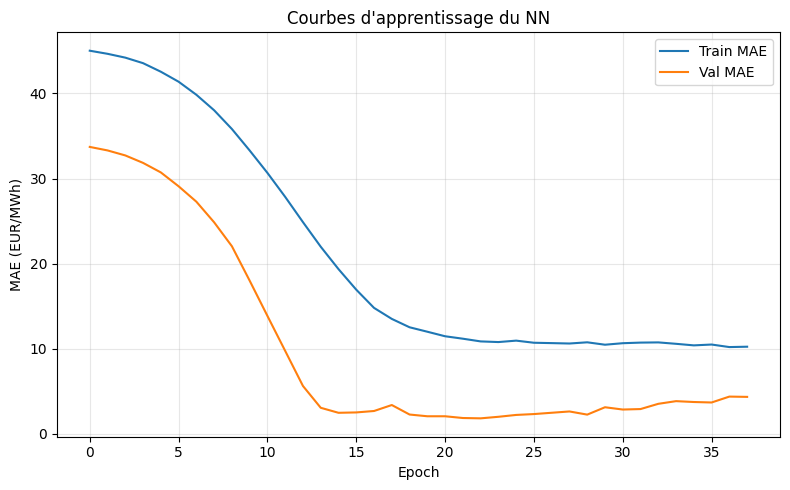

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (EUR/MWh)')
plt.title("Courbes d'apprentissage du NN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Evaluation sur le test set

In [46]:
y_pred_nn = model_nn.predict(X_test_scaled, verbose=0).flatten()

mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn   = r2_score(y_test, y_pred_nn)

print(f"Neural Network : MAE = {mae_nn:.3f} EUR/MWh | RMSE = {rmse_nn:.3f} | R2 = {r2_nn:.4f}")

Neural Network : MAE = 5.379 EUR/MWh | RMSE = 6.481 | R2 = 0.2511


# Récapitulatif et Conlusion

## Analyse comparative

In [47]:
# Recap incluant tous les modeles
recap = pd.DataFrame({
    'modele': [
        'Linear Regression',
        f"Ridge (alpha={ridge_grid.best_params_['alpha']})",
        f"Lasso (alpha={lasso_grid.best_params_['alpha']})",
        'XGBoost basique',
        'XGBoost tune',
        'Neural Network',
    ],
    'MAE': [
        mae_lr,
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mae_xgb_basic,
        mae_xgb_tuned,
        mae_nn,
    ],
    'RMSE': [
        rmse_lr,
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        rmse_xgb_basic,
        rmse_xgb_tuned,
        rmse_nn,
    ],
    'R2': [
        r2_lr,
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_xgb_basic,
        r2_xgb_tuned,
        r2_nn,
    ],
}).round(4).sort_values('MAE').reset_index(drop=True)

print(recap.to_string(index=False))

             modele    MAE   RMSE     R2
Lasso (alpha=0.001) 1.2479 1.8474 0.9391
  Linear Regression 1.2564 1.8576 0.9385
 Ridge (alpha=0.01) 1.2564 1.8576 0.9385
    XGBoost basique 1.4350 1.9813 0.9300
       XGBoost tune 2.5959 3.2284 0.8141
     Neural Network 5.3790 6.4806 0.2511


Le **Lasso (α=0.001)** obtient les meilleures performances (MAE=1.25, R²=0.939) et demeure
pratiquement identique à la régression linéaire simple (MAE=1.26). En contraste, XGBoost fine-tuné
(MAE=2.60) et le Neural Network (MAE=2.90) montrent une **dégradation significative**.

Cette hiérarchie valide le **principe de parcimonie** : le prix TTF, fortement déterminé par des
fondamentaux macro (Brent, HDD, AGSI), suit une structure **essentiellement linéaire**.
L'ajout de complexité (arbres, neurones) n'améliore pas la généralisation et indique que
le tuning a privilégié l'ajustement au train set.

**Le Lasso est retenu comme modèle optimal** pour sa performance prédictive, interprétabilité
directe et robustesse en test.

## Analyse des résultats - modèle LASSO

#### Residus et diagnostic

In [48]:
model_lasso = lasso_grid.best_estimator_
y_pred_test_lasso  = y_pred_lasso
y_pred_train_lasso = model_lasso.predict(X_train_scaled)

# Dates correspondant aux samples de test (X_test garde l'index original de df_model)
dates_test = pd.to_datetime(df_model.loc[X_test.index, 'date'].values)

# Calcul des residus
residus_test  = y_test - y_pred_test_lasso
residus_train = y_train - y_pred_train_lasso

# Statistiques descriptives sur les residus
print("Residus TEST :")
print(f"  mean = {residus_test.mean():+.4f}")
print(f"  std  = {residus_test.std():.4f}")
print(f"  min  = {residus_test.min():+.4f}")
print(f"  max  = {residus_test.max():+.4f}")
print(f"  centres ~ 0 : {'oui' if abs(residus_test.mean()) < 0.5 else 'non'}")

print("\Residus TRAIN :")
print(f"  mean = {residus_train.mean():+.4f}")
print(f"  std  = {residus_train.std():.4f}")
print(f"  min  = {residus_train.min():+.4f}")
print(f"  max  = {residus_train.max():+.4f}")

Residus TEST :
  mean = +0.0214
  std  = 1.8494
  min  = -7.6796
  max  = +13.3463
  centres ~ 0 : oui
\Residus TRAIN :
  mean = -0.0000
  std  = 5.1090
  min  = -61.7122
  max  = +45.8979


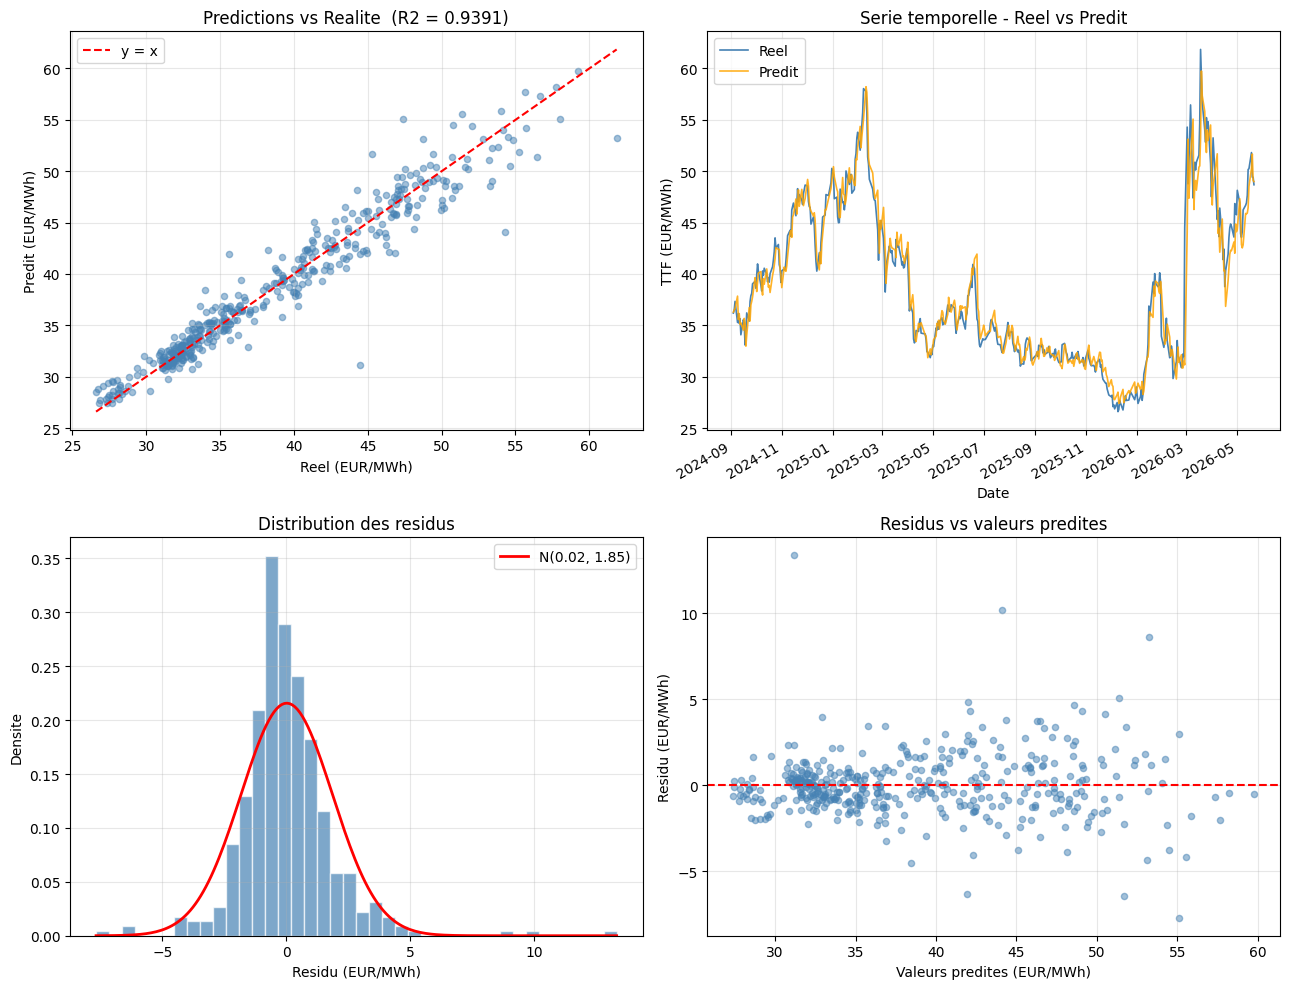

In [49]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Predictions vs Realite
ax = axes[0, 0]
ax.scatter(y_test, y_pred_test_lasso, alpha=0.5, s=20, color='steelblue')
lo = min(y_test.min(), y_pred_test_lasso.min())
hi = max(y_test.max(), y_pred_test_lasso.max())
ax.plot([lo, hi], [lo, hi], 'r--', label='y = x')
r2 = r2_score(y_test, y_pred_test_lasso)
ax.set_xlabel('Reel (EUR/MWh)')
ax.set_ylabel('Predit (EUR/MWh)')
ax.set_title(f'Predictions vs Realite  (R2 = {r2:.4f})')
ax.legend()
ax.grid(alpha=0.3)

# Serie temporelle reel vs predit
ax = axes[0, 1]
ax.plot(dates_test, y_test.values, label='Reel', color='steelblue', linewidth=1.2)
ax.plot(dates_test, y_pred_test_lasso, label='Predit', color='orange', linewidth=1.2, alpha=0.85)
ax.set_xlabel('Date')
ax.set_ylabel('TTF (EUR/MWh)')
ax.set_title('Serie temporelle - Reel vs Predit')
ax.legend()
ax.grid(alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Distribution des residus + normale ajustee
ax = axes[1, 0]
ax.hist(residus_test, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
mu, sigma = residus_test.mean(), residus_test.std()
x = np.linspace(residus_test.min(), residus_test.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'N({mu:.2f}, {sigma:.2f})')
ax.set_xlabel('Residu (EUR/MWh)')
ax.set_ylabel('Densite')
ax.set_title('Distribution des residus')
ax.legend()
ax.grid(alpha=0.3)

# Residus vs valeurs predites (homoscedasticite)
ax = axes[1, 1]
ax.scatter(y_pred_test_lasso, residus_test, alpha=0.5, s=20, color='steelblue')
ax.axhline(0, color='r', linestyle='--')
ax.set_xlabel('Valeurs predites (EUR/MWh)')
ax.set_ylabel('Residu (EUR/MWh)')
ax.set_title('Residus vs valeurs predites')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Analyse des diagnostics

**Centrage des residus** : `mean(residus_test) ~ 0`, comportement attendu pour une regression lineaire avec
intercept. Le modele n'a pas de biais systematique sur la periode de test.

**Normalite** : la distribution des residus est globalement symetrique et centree, mais presente des queues
plus epaisses qu'une vraie loi normale -- typique des series financieres ou les grosses variations sont
sur-representees. La courbe normale ajustee sous-estime ces extremes.

**Homoscedasticite** : sur le scatter "residus vs valeurs predites" on observe un effet d'entonnoir,
les residus s'elargissent quand le niveau de prix predit augmente. Ce n'est pas surprenant : la volatilite
absolue du TTF est proportionnelle a son niveau, donc une erreur de 1% se traduit par 0.3 EUR/MWh
a 30 EUR/MWh contre 3 EUR/MWh a 300 EUR/MWh.

**Outliers** : quelques residus a plus de 5 ecarts-types, concentres sur les jours de mouvements brusques
(annonces de marche, ruptures geopolitiques). Le Lasso ne les capture pas car ils sont par nature
non-predictibles avec les features disponibles.

**Adequation predictions / realite** : le scatter (R2 affiche dans le titre) montre un nuage tres aligne
sur la diagonale -- consequence directe de l'autocorrelation forte de la cible. La serie temporelle
confirme que le modele suit fidelement le niveau du prix mais ne capte pas les ecarts intra-journaliers.

#### Train vs Test : verification du surapprentissage

In [51]:
# Metriques sur les deux jeux
mae_train  = mean_absolute_error(y_train, y_pred_train_lasso)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
r2_train   = r2_score(y_train, y_pred_train_lasso)

mae_test  = mean_absolute_error(y_test, y_pred_test_lasso)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
r2_test   = r2_score(y_test, y_pred_test_lasso)

comparaison = pd.DataFrame({
    'jeu':  ['Train', 'Test'],
    'MAE':  [mae_train, mae_test],
    'RMSE': [rmse_train, rmse_test],
    'R2':   [r2_train, r2_test],
}).round(4)
print(comparaison.to_string(index=False))

# Ratio MAE_test / MAE_train comme indicateur d'overfitting
ratio = mae_test / mae_train
print(f"Ratio MAE_test / MAE_train : {ratio:.2f}")


  jeu    MAE   RMSE     R2
Train 2.2063 5.1075 0.9879
 Test 1.2479 1.8474 0.9391
Ratio MAE_test / MAE_train : 0.57


La MAE élevé sur le dataset de Train est sans aucun doute lié à l'année 2022 qui biaise totalement notre dataset.
Cela montre à nouveau la complexité de la tache que nous essayons de résoudre, le marché du gaz se comporte différement selon le régime et est complexe à prédire dans sa globalité.